In [251]:
import numpy as np
import pandas as pd
import yfinance as yf
import json
import datetime
import os
import time
import pytz
import matplotlib.pyplot as plt
import scipy
from arch import arch_model
from arch.univariate import GARCH
import math

In [252]:
def get_daily_log_returns(symbol, start_date, end_date):
    eastern = pytz.timezone('US/Eastern')
    stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
    stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
    stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
    stockprices['close_prev'] = stockprices['Close'].shift(1)
    stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
    stockprices = stockprices[(stockprices['Date']>eastern.localize(start_date)) & (stockprices['Date']<eastern.localize(end_date))]
    return stockprices['log_ret']

In [282]:
symbol='LLY'
start_date = datetime.datetime(2023,5,20, 0,0,0)
end_date = datetime.datetime(2024,5,20, 0,0,0)
get_daily_log_returns(symbol, start_date, end_date)

12853   -0.019148
12854   -0.025153
12855    0.006031
12856    0.003610
12857   -0.003563
           ...   
13098   -0.003031
13099    0.008254
13100    0.031415
13101   -0.020410
13102   -0.001453
Name: log_ret, Length: 250, dtype: float64

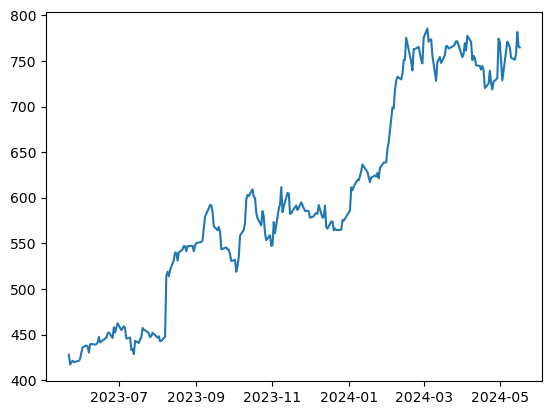

In [283]:
eastern = pytz.timezone('US/Eastern')
stockprices = pd.read_csv(f'StockPriceData/{symbol}.csv')
stockprices['Date'] = pd.to_datetime(stockprices['Date'], utc=True)
stockprices['Date'] = stockprices['Date'].dt.tz_convert('US/Eastern')
stockprices['close_prev'] = stockprices['Close'].shift(1)
stockprices['log_ret'] = np.log(stockprices['Close']/stockprices['close_prev'])
stockprices = stockprices[(stockprices['Date']>eastern.localize(start_date)) & (stockprices['Date']<eastern.localize(end_date))]
plt.plot(stockprices['Date'], stockprices['Close'])
plt.show()

In [255]:
def get_garch_params(log_rets):
    model = arch_model(100*log_rets, vol='GARCH', p=1, q=1)
    res = model.fit()
    print(res.summary)
    return res.params

In [284]:
garch_params = get_garch_params(get_daily_log_returns(symbol, start_date, end_date))

Iteration:      1,   Func. Count:      6,   Neg. LLF: 906.9952677321054
Iteration:      2,   Func. Count:     13,   Neg. LLF: 515.8221947164303
Iteration:      3,   Func. Count:     20,   Neg. LLF: 509.82062604949124
Iteration:      4,   Func. Count:     25,   Neg. LLF: 509.8189151538341
Iteration:      5,   Func. Count:     30,   Neg. LLF: 509.81065952009175
Iteration:      6,   Func. Count:     35,   Neg. LLF: 509.8001645951047
Iteration:      7,   Func. Count:     40,   Neg. LLF: 509.79026511160896
Iteration:      8,   Func. Count:     45,   Neg. LLF: 509.76174716139064
Iteration:      9,   Func. Count:     50,   Neg. LLF: 509.75937647150107
Iteration:     10,   Func. Count:     55,   Neg. LLF: 509.7570915107941
Iteration:     11,   Func. Count:     60,   Neg. LLF: 509.7568160053778
Iteration:     12,   Func. Count:     65,   Neg. LLF: 509.75678997763805
Iteration:     13,   Func. Count:     69,   Neg. LLF: 509.75678997852214
Optimization terminated successfully    (Exit mode 0)
   

In [285]:
garch_params

mu          2.247342e-01
omega       3.456115e+00
alpha[1]    0.000000e+00
beta[1]     2.945584e-09
Name: params, dtype: float64

In [286]:
garch_params.loc['alpha[1]']

0.0

In [132]:
horizon = 252             # Forecast horizon (e.g., 10 steps)

simulation = model.simulate(res.params, nobs=horizon)
simulation
#simulation['data'].to_numpy()/100

,data,volatility,errors
0,-0.626589,1.178371,-0.686496
1,-0.071959,1.209097,-0.131865
2,-0.688497,1.178905,-0.748404
3,-1.556863,1.214918,-1.616769
4,1.471503,1.342486,1.411597
...,...,...,...
247,0.604024,1.284692,0.544117
248,-2.131500,1.197532,-2.191407
249,0.309956,1.466245,0.250050
250,-1.185365,1.181942,-1.245272


In [259]:
def simulate_from_garch_params(sigma_start, omega, alpha, beta, n_paths, n_steps):
    garch = GARCH(p=1, q=1)
    errors = np.zeros((n_paths, n_steps))
    variances = np.zeros((n_paths, n_steps))
    for i in range(n_paths):
        output = garch.simulate(
            parameters=[omega, alpha, beta],
            nobs=n_steps,
            initial_value=sigma_start**2,  # starting sigma² (variance)
            rng=np.random.standard_normal
        )
        errors[i]=output[0]
        variances[i]=output[1]
    return (errors, variances)

In [260]:
def stock_path_garch_sigma(S0, r, n_paths, t, garch_params):
    '''
    Generation of custom stock paths following Geometeric Brownian motion,
    but log-returns do not have constant volatility.
    
    Each step of the log-returns, there is a 
    1) 50% the volatility is .2
    2) 30% chance the volatility is .3
    3) 20% chance the volatility is .45
    
    Inputs:
    S0 (float): initial stock value
    t (float): time interval of stock path movements in years
    r (float): risk-free interest rate
    mu (float): drift of log-returns
    n_paths (int): number of stock paths
    n_steps (float): number of steps in each stock path
    
    Returns:
    
    Simuatled stock paths
    '''
    n_steps=math.ceil(t*252)
    #Custom sigma that is not constant

    simulated_sigma = simulate_from_garch_params(sigma_start=garch_params.omega, omega=garch_params.omega, alpha=garch_params.loc['alpha[1]'], beta=garch_params.loc['beta[1]'], n_paths=n_paths, n_steps=n_steps)
    sigma_adjusted = simulated_sigma[0]/100
    
    #sigma = np.zeros((n_paths, n_steps))

    # for i in range(n_paths):
    #     simulation = model.simulate(res.params, nobs=n_steps)
    #     sigma[i] = simulation['errors'].to_numpy()/100
        
    noise = np.random.normal(0,1,(n_paths,n_steps))
  
    
    #log-returns between each step
    #increments = (r)*(1/252) + sigma - .5*sigma**2
    increments = (garch_params.mu/100 + r*(1/252) - .5*sigma_adjusted**2) + sigma_adjusted*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths = S0*np.exp(log_returns)
    
    
    #Adjoint initial value S0 at start of each simulated path
    
    
    
    return paths
    
    

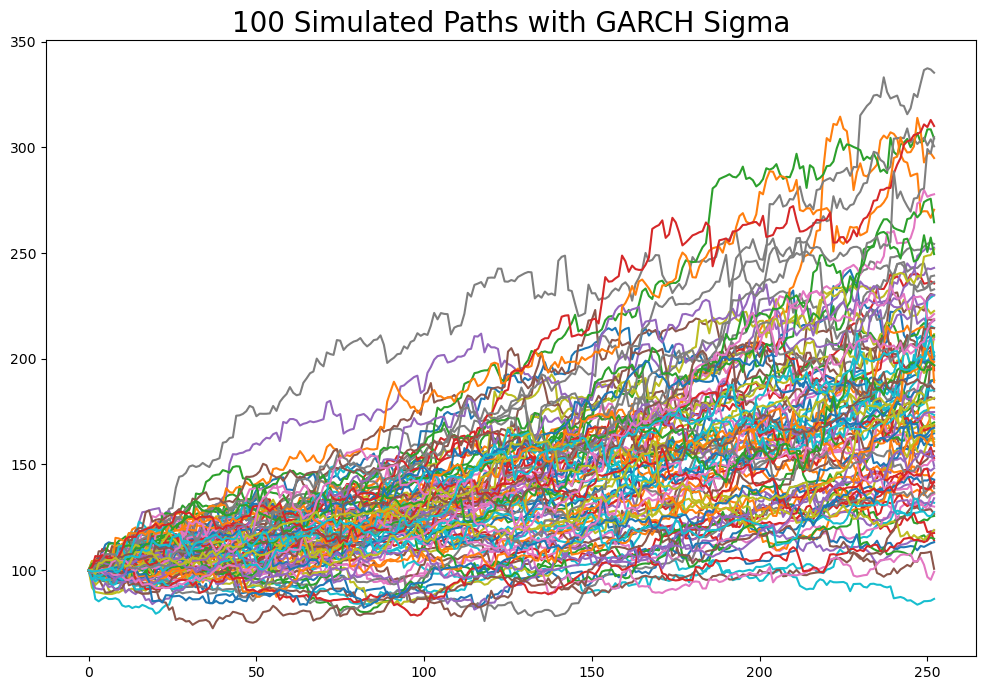

In [287]:
#5 Simulated paths of daily steps over 1-year period and plot

S0 = 100
r = 0.039
n_paths = 100
t=1


simulated_paths = stock_path_garch_sigma(S0, r, n_paths, t, garch_params)
simulated_paths = np.insert(simulated_paths, 0, S0, axis = 1)


plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with GARCH Sigma', size = 20)


plt.show()

In [264]:
#Create function that does monte-carlo simulation of call option price with volatility modeled using GARCH process

def mc_sim_call_garch(S0, K, r, n_paths, t, garch_params):
    """
    Monte Carlo simulation to estimate the price of a European call option 
    under the Black-Scholes model.

    Parameters:
        S0 (float): Initial stock price
        K (float): Strike price
        sigma (float): Volatility of the stock
        t (float): Time to maturity (in years)
        r (float): Risk-free interest rate
        N (int): Number of simulated paths

    Returns:
        float: Estimated call option price
    """

    #paths
    paths = stock_path_garch_sigma(S0, r, n_paths, t, garch_params)

    end_points = paths[:,-1]
    
    call_payouts = np.maximum(end_points - K, 0)

    call_sim_value = np.exp(-r)*np.mean(call_payouts)

    return call_sim_value
    

In [288]:
S0 = 100
r = 0.039
n_paths = 500
t=1
K=110

for i in range(5):
    print(mc_sim_call_garch(S0, K, r, n_paths, t, garch_params))

72.28521575987469
73.93992307017814
70.4967820126632
71.0908659546761
70.9319036686256


In [346]:
def mc_sim_call_garch_delta(S0, K, t, r, n_paths, garch_params):

    n_steps = math.ceil(t*252)
    #simulate path endpoints

    bump = .01*S0 #epsilon in above estimation

    simulated_sigma = simulate_from_garch_params(sigma_start=garch_params.omega, omega=garch_params.omega, alpha=garch_params.loc['alpha[1]'], beta=garch_params.loc['beta[1]'], n_paths=n_paths, n_steps=n_steps)
    sigma_adjusted = simulated_sigma[0]/100
        
    noise = np.random.normal(0,1,(n_paths,n_steps))
    
    
    increments = (garch_params.mu/100 + r*(1/252) - .5*sigma_adjusted**2) + sigma_adjusted*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    #print(S0*log_returns[:,-1])

    #paths
    paths_up = (S0+bump)*np.exp(log_returns[:,-1])

    paths_down = (S0-bump)*np.exp(log_returns[:,-1])

    calls_up = np.mean(np.maximum(paths_up - K, 0)*np.exp(-r*t), axis=1)

    calls_down = np.mean(np.maximum(paths_down - K, 0)*np.exp(-r*t), axis=1)

    print(calls_up-calls_down)
    print(2*bump.reshape(1,-1))
    delta_sims = (calls_up - calls_down)/(2*bump.reshape(1,-1))

    return delta_sims



In [348]:
S0 = np.array([[100]])
r = 0.039
n_paths = 100
K=110
t=1

mc_sim_call_garch_delta(S0, K, t, r, n_paths, garch_params)

[3.50900301]
[[2.]]


array([[1.75450151]])

In [326]:
def mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims = 2500, n_hedges = 50, delta_sims = 250):

    hedge_time_points = np.vectorize(math.ceil)(np.linspace(0, 1, n_hedges + 1)*t*252)


    # noise = np.random.normal(0,1,(n_sims,n_hedges))

    # #time interval between each step in simulated path
    if n_hedges !=0:
        dt = t/n_hedges

    # increments = (mu+r - .5*sigma**2)*dt + sigma*np.sqrt(dt)*noise #log_return increments

    # log_returns = np.cumsum(increments, axis = 1)



    # paths = S0*np.exp(log_returns)

    paths = stock_path_garch_sigma(S0, r, n_sims, t, garch_params)
    paths = np.insert(paths, 0, S0, axis = 1)

    #Simulate call payouts discounted to time 0

    path_end_points = paths[:,-1]

    call_payouts = np.maximum(path_end_points - K,0)*np.exp(-r*t)



    #Simulate stock profits at each interval

    ## profit from start to first step discounted to time 0
    ### We are going to cheat at the current moment in our simulation
    ### We will use the Black-Scholes formula to find Delta,
    ### We'll simulate Delta later

    # delta_start = mc_sim_call_garch_delta(np.array([[S0]]),K, t,r,delta_sims, garch_params)

    # paths_first_hedge_endpoint = paths[:,0]

    # first_stock_profits = (paths_first_steps*np.exp(-dt*r) - S0)*delta_start

    stock_profits = []

    # stock_profits.append(first_stock_profits)


    ## stock profits in intermediate steps

    for i in range(0,n_hedges):
        stock_start = paths[:,hedge_time_points[i]]
        stock_end = paths[:,hedge_time_points[i+1]]
        tte = t-i*dt
        deltas = mc_sim_call_garch_delta(stock_start.reshape(-1,1), K, tte, r,delta_sims, garch_params)
        print(deltas)
        stock_profit = (stock_end - stock_start*np.exp(r*dt))*deltas*np.exp(-(i+1)*dt*r)
        stock_profits.append(stock_profit)

    
    total_stock_profit = np.sum(stock_profits, axis = 0)
    print(total_stock_profit)
    print(call_payouts)

    profits_hedged = call_payouts - total_stock_profit
    
    
    return profits_hedged


In [327]:
S0 = 100
r = 0.039
n_paths = 5
K=120
t=1

mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims = 5, n_hedges = 1, delta_sims = 500)

[1.64754632 1.64754632 1.64754632 1.64754632 1.64754632]
[170.44313511  37.18034312  45.59230452  54.96517797 140.5626721 ]
[88.04262719  7.15701528 12.26276637 17.95175572 69.90628546]


array([-82.40050793, -30.02332784, -33.32953815, -37.01342225,
       -70.65638664])

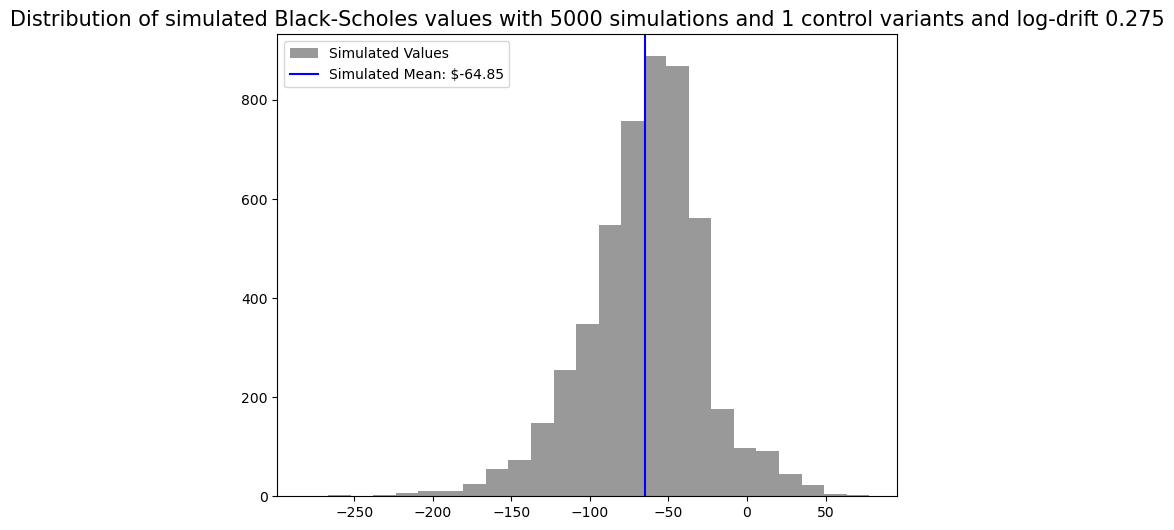

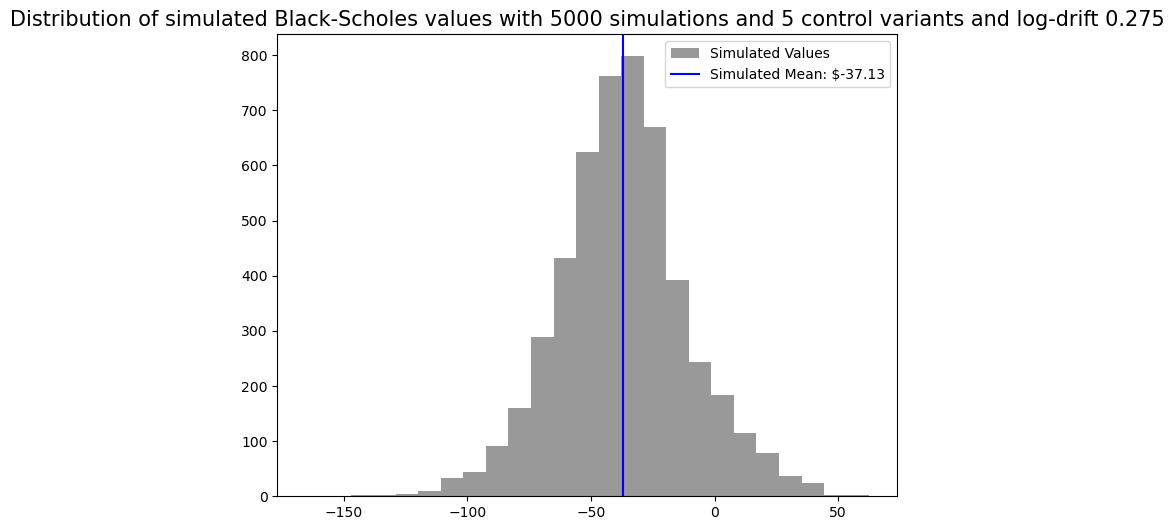

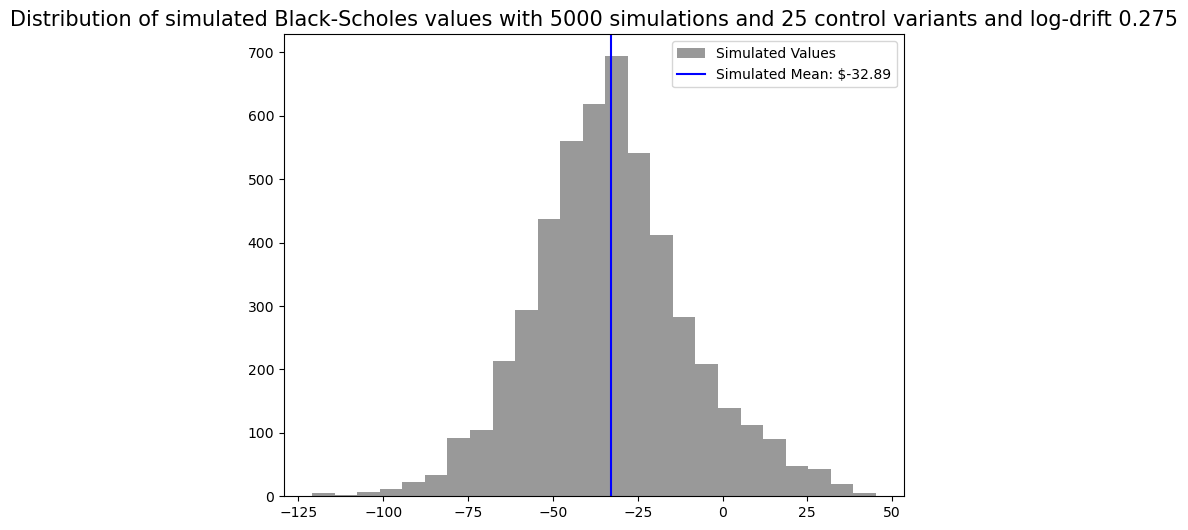

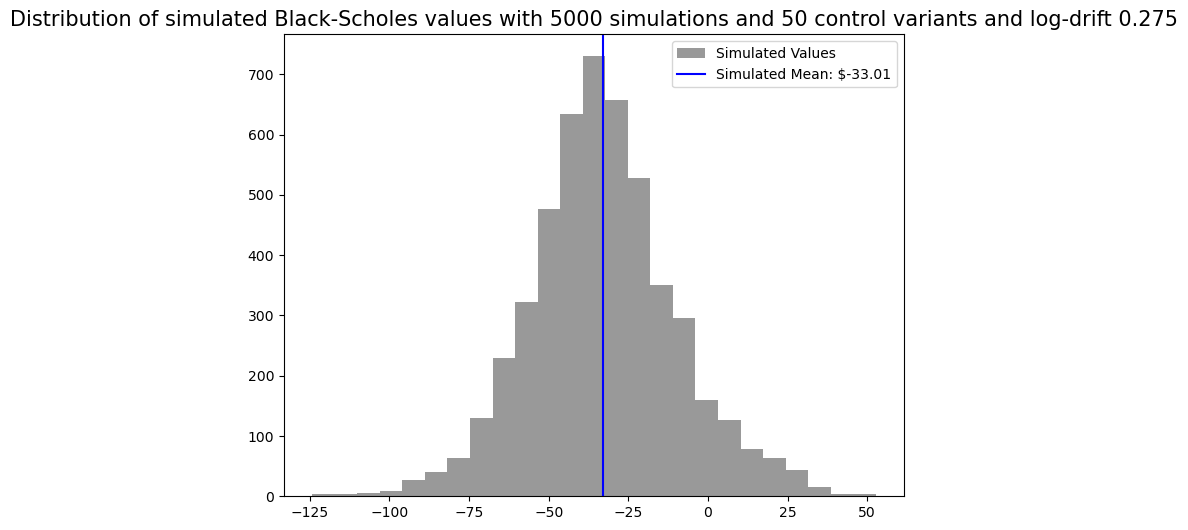

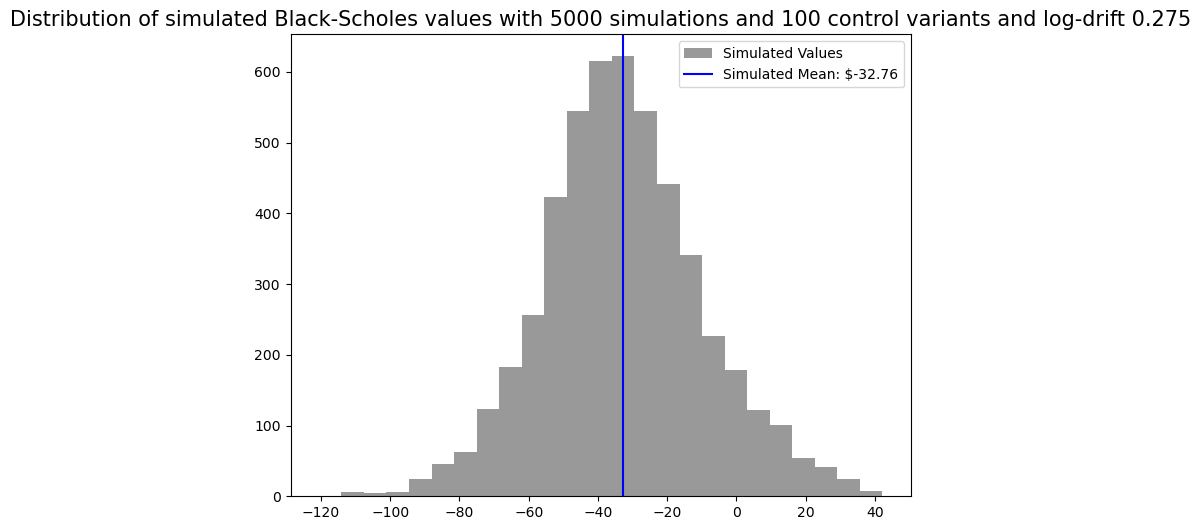

In [316]:
S0 = 100
K = 120
#sigma = .5
t = 1
r = 0.04
#mu = .35 #Drift of stock movement
delta_sims = 500

n_sims = 5000

hedging_numbers = [1, 5, 25, 50, 100]

#bs_price = bs_call(S0,K,sigma,t,r)

for n_hedges in hedging_numbers:
    #profits_hedged = bs_MC_call(S0, K, sigma, r, t, mu, n_sims, n_hedges, delta_sims)
    profits_hedged = mc_sim_call_garch_delta_hedge(S0, K, garch_params, r, t, n_sims , n_hedges, delta_sims)
    
    plt.figure(figsize = (8,6))
    
    plt.hist(profits_hedged, bins = 25, alpha = .4, color = 'black', label = 'Simulated Values')
    
    #plt.axvline(bs_price, label = f'Black-Scholes Price: ${bs_price:.2f}', color = 'red')
    
    plt.axvline(np.mean(profits_hedged), label = f'Simulated Mean: ${np.mean(profits_hedged):.2f}', color = 'blue')
    
    plt.legend()
    
    plt.title(f'Distribution of simulated Black-Scholes values with {n_sims} simulations and \
{n_hedges} control variants and log-drift {mu}',size = 15)
    
    plt.show()
